# Sampling-measurement counts for six sampling experiments

Generate the six-panel measurement-count figure directly from the monthly sampled fields and annual experiment masks.


/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Anaconda/envs/xmip/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Original sampling complete


Randomized observed sampling complete


30% uniform sampling complete


2,000 added profiles: Tropical Oceans complete


2,000 added profiles: North Atlantic + North Pacific Oceans complete


2,000 added profiles: Southern Ocean complete


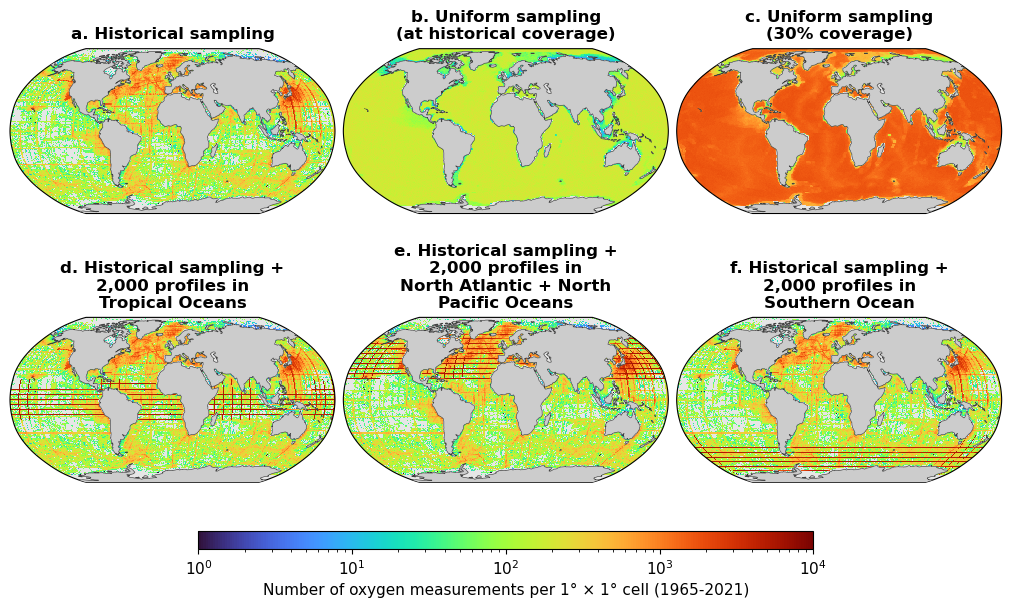

Original sampling: total=8,269,189; maximum cell=4,196
Randomized observed sampling: total=6,866,955; maximum cell=254
30% uniform sampling: total=54,742,884; maximum cell=1,864
2,000 added profiles: Tropical Oceans: total=17,089,336; maximum cell=5,814
2,000 added profiles: North Atlantic + North Pacific Oceans: total=15,856,308; maximum cell=5,814
2,000 added profiles: Southern Ocean: total=17,074,787; maximum cell=5,814
Saved /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures/sampling_measurement_counts_six_panel.pdf


In [1]:
#!/usr/bin/env python3
"""Plot GFDL-ESM4 artificial-experiment sampling counts."""
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd()/".matplotlib").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import netCDF4 as nc
import numpy as np

Y0,Y1=1965,2021
ROOT=Path("/scratch/gpfs/LRGROUP/db9274/GFDL_ESM4_artificial_subsampling")
ORIGINAL=Path("/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis/Variability_quantification/NETCDF/Monthly_O2_subsampled_RB23/o2_1x1bin_subsampled_GFDL_ESM4.nc")
MASKS={
"Randomized observed sampling":ROOT/"annual_masks/annual_mask_GFDL_ESM4_r1i1p1f1_randobs.nc",
"30% uniform sampling":ROOT/"annual_masks/annual_mask_GFDL_ESM4_r1i1p1f1_pct30.nc"}
MONTHLY={
"Original sampling":ORIGINAL}
OUT=Path("Figures/sampling_measurement_counts_six_panel.pdf")
REGIONAL_DIR=ROOT/"Monthly_subsampled_fields_1965_2021/o2"

def annual_counts(path):
    with nc.Dataset(path) as ds:
        v=ds.variables["o2"]
        if v.shape[0]!=(Y1-Y0+1)*12: raise ValueError(f"Unexpected time length in {path}")
        out=np.zeros(v.shape[-2:],np.uint32)
        for yi in range(Y1-Y0+1):
            sampled=np.zeros(v.shape[1:],bool)
            for ti in range(yi*12,(yi+1)*12):
                sampled |= np.isfinite(np.ma.filled(v[ti],np.nan))
            out += sampled.sum(axis=0,dtype=np.uint32)
        lat=np.asarray(ds.variables["y"][:]); lon=((np.asarray(ds.variables["x"][:], dtype=float) + 180) % 360) - 180
    order=np.argsort(lon)
    return out[:,order],lat,lon[order]

def mask_counts(path):
    with nc.Dataset(path) as ds:
        v=ds.variables["sample_mask"]; out=np.zeros(v.shape[-2:],np.uint32)
        for yi in range(v.shape[0]): out += np.asarray(v[yi],np.uint32).sum(axis=0)
        lat=np.asarray(ds.variables["y"][:]); lon=((np.asarray(ds.variables["x"][:], dtype=float) + 180) % 360) - 180
    order=np.argsort(lon)
    return out[:,order],lat,lon[order]

def edges(c,cyclic=False):
    c=np.asarray(c,float); e=np.empty(c.size+1)
    e[1:-1]=(c[:-1]+c[1:])/2; e[0]=c[0]-(c[1]-c[0])/2; e[-1]=c[-1]+(c[-1]-c[-2])/2
    if cyclic:e[0],e[-1]=0,360
    return e

def main():
    required=[*MONTHLY.values(),*MASKS.values()]
    missing=[str(p) for p in required if not p.exists()]
    if missing: raise FileNotFoundError("Missing inputs:\n"+"\n".join(missing))
    loaded={}
    for name,path in MONTHLY.items():
        loaded[name],lat,lon=annual_counts(path); print(name,"complete")
    for name,path in MASKS.items():
        loaded[name],mlat,mlon=mask_counts(path)
        if not(np.allclose(lat,mlat) and np.allclose(lon,mlon)):raise ValueError(f"Grid mismatch: {path}")
        print(name,"complete")
    names=["Original sampling","Randomized observed sampling","30% uniform sampling"]
    fields=[(n,loaded[n]) for n in names]
    regional_specs=[
        ("2,000 added profiles: Tropical Oceans", REGIONAL_DIR/"o2_1x1bin_GFDL_ESM4_r1i1p1f1_regional_tropical_2000.nc"),
        ("2,000 added profiles: North Atlantic + North Pacific Oceans", REGIONAL_DIR/"o2_1x1bin_GFDL_ESM4_r1i1p1f1_regional_extratropical_2000.nc"),
        ("2,000 added profiles: Southern Ocean", REGIONAL_DIR/"o2_1x1bin_GFDL_ESM4_r1i1p1f1_regional_southern_ocean_2000.nc"),
    ]
    for name,path in regional_specs:
        loaded[name],rlat,rlon=annual_counts(path)
        if not(np.allclose(lat,rlat) and np.allclose(lon,rlon)): raise ValueError(f"Grid mismatch: {path}")
        print(name,"complete"); fields.append((name,loaded[name]))
    positive=np.concatenate([a[a>0] for _,a in fields])
    vmin=1
    vmax=10 ** np.ceil(np.log10(positive.max()))
    norm=LogNorm(vmin=vmin,vmax=vmax); cmap=plt.colormaps["turbo"].copy(); cmap.set_bad("#e6e6e6")
    plt.rcParams.update({"font.size":11,"axes.titlesize":12,"axes.labelsize":11,"xtick.labelsize":11,"ytick.labelsize":11,"axes.titleweight":"normal","savefig.dpi":600,"pdf.fonttype":42})
    fig,axs=plt.subplots(2,3,figsize=(10,6.5),subplot_kw={"projection":ccrs.Robinson(central_longitude=0)},constrained_layout=True)
    panel_titles=["Historical sampling","Uniform sampling\n(at historical coverage)","Uniform sampling\n(30% coverage)","Historical sampling +\n2,000 profiles in\nTropical Oceans","Historical sampling +\n2,000 profiles in\nNorth Atlantic + North\nPacific Oceans","Historical sampling +\n2,000 profiles in\nSouthern Ocean"]
    for ax,letter,(name,a),title in zip(axs.flat,"abcdef",fields,panel_titles):
        lon_edges = edges(lon)
        lat_edges = edges(lat)
        shown = np.ma.masked_equal(a, 0)
        mesh=ax.pcolormesh(lon_edges, lat_edges, shown, transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, shading="flat", rasterized=True)
        ax.add_feature(cfeature.LAND,facecolor="0.8",edgecolor="none",zorder=3); ax.coastlines(linewidth=.45,color=".25",zorder=4); ax.set_global()
        ax.set_title(f"{letter}. {title}", pad=7, fontweight="bold")
    cb=fig.colorbar(mesh, ax=axs, orientation="horizontal", shrink=.62, pad=.08, aspect=35)
    cb.set_label(f"Number of oxygen measurements per 1° × 1° cell ({Y0}-{Y1})")
    OUT.parent.mkdir(exist_ok=True); fig.savefig(OUT,bbox_inches="tight",pad_inches=.03); plt.show(); plt.close(fig)
    for n,a in fields:print(f"{n}: total={int(a.sum()):,}; maximum cell={int(a.max()):,}")
    print(f"Saved {OUT.resolve()}")
if __name__=="__main__":main()
